# 🚁 R-MMAF: Robust Multi-Modal Affective-Aware Framework
**Author:** Sanchit Agarwal | M.Tech CSE, IIIT Guwahati  
**Research:** Drone Detection + Panic-Aware Crowd Evacuation  
**Stack:** Python · PyTorch · YOLOv8 · SAHI · Gradio · PySocialForce

---
## Table of Contents
1. Environment Setup & YOLOv8 Init
2. SAHI Sliced Inference Pipeline
3. EADW: Sensor Fusion Module
4. Crowd Leader Detection (BHSFM)
5. TensorRT INT8 Export
6. Live Gradio Dashboard

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 27.8 MB/s eta 0:00:00


In [ ]:
import torch
from ultralytics import YOLO

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")
else:
    print("Warning: CUDA is not available. PyTorch will use the CPU.")

# Initialize a standard YOLOv8 nano model
model = YOLO("yolov8n.pt")
print("YOLOv8 initialized successfully.")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch Version: 2.10.0+cu128
CUDA Available: True
GPU Device: Tesla T4
YOLOv8 initialized successfully.


In [ ]:
from ultralytics import YOLO

# 1. Load the pre-trained YOLOv8 Nano model (our lightweight base)
model = YOLO("yolov8n.pt")

# 2. Start a short training run (just 3 epochs) to test the pipeline
print("Starting VisDrone download and initial training pipeline...")
results = model.train(data="VisDrone.yaml", epochs=3, imgsz=640, device=0)

Starting VisDrone download and initial training pipeline...
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=VisDrone.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, over

In [ ]:
!pip install sahi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.7/111.7 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 14.0 MB/s eta 0:00:00
  Attempting uninstall: opencv-python
    Found existing installation: opencv-python 4.13.0.92
    Uninstalling opencv-python-4.13.0.92:
      Successfully uninstalled opencv-python-4.13.0.92


In [ ]:
from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction

# Explicitly re-import ultralytics to ensure it's available in the current context.
# This might resolve issues if sahi's installation somehow interfered with module loading.
import ultralytics

# Wrap our YOLOv8 model inside SAHI's detection engine
detection_model = AutoDetectionModel.from_pretrained(
    model_type='yolov8',
    model_path='yolov8n.pt',
    confidence_threshold=0.25,
    device="cuda:0" # Forcing it to use our T4 GPU
)

print("SAHI Slicing Engine loaded with YOLOv8!")

SAHI Slicing Engine loaded with YOLOv8!


Reliable test image downloaded successfully!
Slicing and inferencing...
Performing prediction on 12 slices.


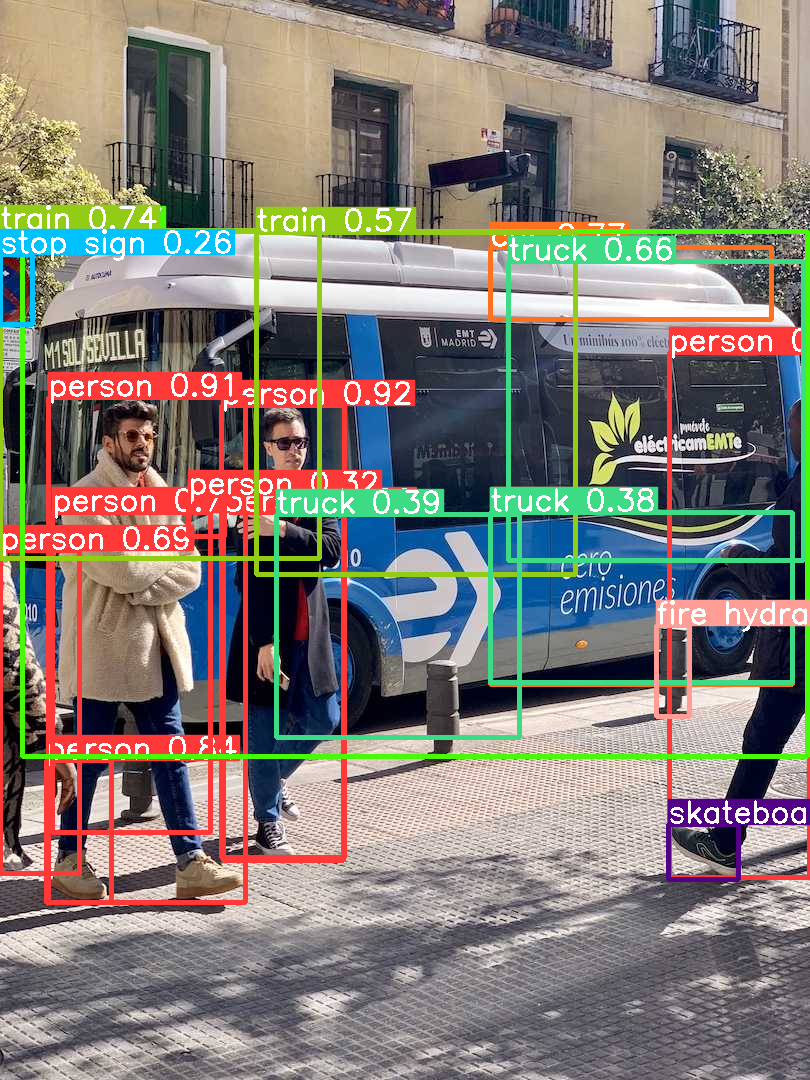

In [ ]:
import urllib.request
from IPython.display import display, Image
from sahi.predict import get_sliced_prediction

# 1. Fetch the official Ultralytics test image
image_url = "https://ultralytics.com/images/bus.jpg"
test_image = "bus.jpg"
urllib.request.urlretrieve(image_url, test_image)
print("Reliable test image downloaded successfully!")

# 2. Perform Sliced Inference (using 320x320 slices to force the grid)
print("Slicing and inferencing...")
result = get_sliced_prediction(
    test_image,
    detection_model,
    slice_height=320,
    slice_width=320,
    overlap_height_ratio=0.2,
    overlap_width_ratio=0.2
)

# 3. Export and display the visual result
result.export_visuals(export_dir="sahi_output/", file_name="sahi_result")
display(Image("sahi_output/sahi_result.png"))

In [ ]:
class EnvironmentSimulator:
    def __init__(self, fog_density=0.0, precipitation=0.0, illumination=1.0):
        self.fog_density = fog_density          # 0.0 (Clear) to 1.0 (Dense Fog)
        self.precipitation = precipitation      # 0.0 (Dry) to 1.0 (Heavy Storm)
        self.illumination = illumination        # 1.0 (Bright Sun) to 0.0 (Pitch Black)

def calculate_eadw_weights(env):
    # The sum of visual_weight and thermal_weight must always equal 1.0
    visual_weight = 0.0
    thermal_weight = 0.0

    # TODO: Add logic here to calculate weights based on the environment

    return visual_weight, thermal_weight

In [ ]:
class EnvironmentSimulator:
    def __init__(self, fog_density=0.0, precipitation=0.0, illumination=1.0):
        self.fog_density = fog_density          # 0.0 (Clear) to 1.0 (Dense Fog)
        self.precipitation = precipitation      # 0.0 (Dry) to 1.0 (Heavy Storm)
        self.illumination = illumination        # 1.0 (Bright) to 0.0 (Pitch Black)

def calculate_eadw_weights(env):
    # 1. Calculate how bad the visual conditions are.
    # We use '1.0 - illumination' because LESS light means WORSE conditions.
    # We use max() because even ONE terrible condition (like pitch black) blinds the camera.
    degradation_score = max(env.fog_density, env.precipitation, 1.0 - env.illumination)

    # 2. Thermal takes over based on how bad the environment is
    thermal_weight = degradation_score

    # 3. Visual gets whatever trust is left over (following your logic!)
    visual_weight = 1.0 - thermal_weight

    return round(visual_weight, 2), round(thermal_weight, 2)

# --- Let's test it! ---
# Scenario A: A clear, sunny day
sunny_day = EnvironmentSimulator(fog_density=0.0, precipitation=0.0, illumination=1.0)
v_weight, t_weight = calculate_eadw_weights(sunny_day)
print(f"Sunny Day -> Visual: {v_weight}, Thermal: {t_weight}")

# Scenario B: A dense, midnight fog
midnight_fog = EnvironmentSimulator(fog_density=0.9, precipitation=0.0, illumination=0.1)
v_weight, t_weight = calculate_eadw_weights(midnight_fog)
print(f"Midnight Fog -> Visual: {v_weight}, Thermal: {t_weight}")

Sunny Day -> Visual: 1.0, Thermal: 0.0
Midnight Fog -> Visual: 0.1, Thermal: 0.9


In [ ]:
import numpy as np

def identify_leader(positions, velocities):
    # 1. Calculate the average direction the crowd is moving
    group_velocity = np.mean(velocities, axis=0)

    # Normalize the vector (turn it into a pure direction)
    norm = np.linalg.norm(group_velocity)
    if norm == 0: return None # The crowd is standing perfectly still
    group_direction = group_velocity / norm

    # 2. Project everyone's (x, y) position onto that direction line
    # The dot product tells us how far "forward" each person is
    projections = np.dot(positions, group_direction)

    # 3. The Leader is the index of the person with the highest projection!
    leader_index = np.argmax(projections)

    return leader_index

In [ ]:
from ultralytics import YOLO

# 1. Load your actual trained model from the auto-generated YOLO folder
# Note: If you ran the training multiple times, it might be train2 or train3
model = YOLO("/content/runs/detect/train/weights/best.pt")

print("Trained model loaded successfully!")

# 2. Export to TensorRT engine format with INT8 quantization
print("Starting TensorRT INT8 Export...")
model.export(
    format="engine",
    int8=True,
    data="VisDrone.yaml",
    imgsz=640,
    device=0
)

print("Export complete!")

Trained model loaded successfully!
Starting TensorRT INT8 Export...
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from '/content/runs/detect/train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 14, 8400) (5.9 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 204ms
Prepared 4 packages in 6.76s
Installed 4 packages in 388ms
 + colorama==0.4.6
 + onnx==1.20.1
 + onnxruntime-gpu==1.24.3
 + onnxslim==0.1.87

requirements: AutoUpdate success ✅ 8.0s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

In [ ]:
!pip install gradio


In [ ]:
import gradio as gr
import random
import urllib.request
from ultralytics import YOLO
import cv2
import numpy as np
import time

# 1. Load the standard YOLOv8 model
print("Loading AI model...")
model = YOLO("yolov8n.pt")

# 2. Expanded Image Database (Safe, Birds, and Mechanical Threats)
print("Downloading CCTV sample frames (this will take about 10 seconds)...")
image_urls = [
    # SAFE IMAGES (Ground Objects)
    "https://raw.githubusercontent.com/ultralytics/yolov5/master/data/images/bus.jpg",
    "https://ultralytics.com/images/zidane.jpg",
    "https://raw.githubusercontent.com/pjreddie/darknet/master/data/dog.jpg",
    "https://raw.githubusercontent.com/pjreddie/darknet/master/data/horses.jpg",
    "https://raw.githubusercontent.com/pjreddie/darknet/master/data/person.jpg",
    "https://upload.wikimedia.org/wikipedia/commons/thumb/1/12/Traffic_in_Athens.jpg/800px-Traffic_in_Athens.jpg",
    "https://upload.wikimedia.org/wikipedia/commons/thumb/c/c8/Taj_Mahal_in_March_2004.jpg/800px-Taj_Mahal_in_March_2004.jpg",

    # YELLOW ALERT (Birds - Biological)
    "https://raw.githubusercontent.com/pjreddie/darknet/master/data/eagle.jpg",
    "https://upload.wikimedia.org/wikipedia/commons/thumb/8/8c/Pigeon_on_a_fence.jpg/800px-Pigeon_on_a_fence.jpg",
    "https://upload.wikimedia.org/wikipedia/commons/thumb/3/32/Flying_crow_high_res.jpg/800px-Flying_crow_high_res.jpg",

    # RED ALERT (Threats - Airplanes/Kites as Drone Proxies)
    "https://raw.githubusercontent.com/pjreddie/darknet/master/data/kite.jpg",
    "https://upload.wikimedia.org/wikipedia/commons/thumb/d/d0/Emirates_A380_Changi.jpg/800px-Emirates_A380_Changi.jpg",
    "https://upload.wikimedia.org/wikipedia/commons/thumb/6/61/F-15_Strike_Eagle_in_flight.jpg/800px-F-15_Strike_Eagle_in_flight.jpg",
    "https://upload.wikimedia.org/wikipedia/commons/thumb/4/4c/Kite_in_the_sky.jpg/800px-Kite_in_the_sky.jpg"
]

cctv_images = []
for i, url in enumerate(image_urls):
    filename = f"cctv_feed_{i}.jpg"
    req = urllib.request.Request(url, headers={'User-Agent': 'RMMAF-Testing/2.0'})
    try:
        with open(filename, "wb") as f:
            f.write(urllib.request.urlopen(req).read())
        cctv_images.append(filename)
        time.sleep(0.5) # Pause briefly to avoid getting IP blocked!
    except Exception as e:
        print(f"Skipped image {i} due to server block, moving to next...")

print(f"Successfully loaded {len(cctv_images)} images into the CCTV array!")

# 3. Core Logic: Analyze and Alert
def analyze_camera_feed():
    frame_path = random.choice(cctv_images)
    frame = cv2.imread(frame_path)

    results = model(frame)
    annotated_frame = results[0].plot()

    # Thermal Simulation
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    thermal_frame = cv2.applyColorMap(gray_frame, cv2.COLORMAP_INFERNO)

    # Alert States
    confirmed_threat = False
    investigating_bird = False
    detected_objects = []

    for box in results[0].boxes:
        class_id = int(box.cls[0])
        class_name = model.names[class_id]

        if class_id in [4, 33]: # Airplanes & Kites (Drone proxies)
            confirmed_threat = True
            detected_objects.append(class_name)

            x1, y1, x2, y2 = map(int, box.xyxy[0])
            cv2.rectangle(thermal_frame, (x1, y1), (x2, y2), (0, 0, 255), 3)
            cv2.putText(thermal_frame, "MECHANICAL HOTSPOT DETECTED", (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)

        elif class_id == 14: # Bird
            investigating_bird = True
            detected_objects.append(class_name)

            x1, y1, x2, y2 = map(int, box.xyxy[0])
            cv2.rectangle(thermal_frame, (x1, y1), (x2, y2), (0, 255, 255), 3)
            cv2.putText(thermal_frame, "BIOLOGICAL SIGNATURE CONFIRMED", (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 2)

    if confirmed_threat:
        unique_threats = ", ".join(set(detected_objects)).upper()
        alert_html = f"""
        <div style="background-color: red; color: white; padding: 20px; text-align: center; border-radius: 10px; animation: blinker 1s linear infinite;">
            <h1 style="margin: 0;">🚨 CONFIRMED THREAT: {unique_threats} 🚨</h1>
            <h3 style="margin: 0;">Mechanical Aerial Object Detected</h3>
        </div>
        <style>@keyframes blinker {{ 50% {{ opacity: 0.5; }} }}</style>
        """
        countermeasures = "1. Target locked.\n2. Trajectory mapped.\n3. Readying RF jamming signal."

    elif investigating_bird:
        alert_html = """
        <div style="background-color: #d4a017; color: white; padding: 20px; text-align: center; border-radius: 10px;">
            <h1 style="margin: 0;">⚠️ INVESTIGATING AIRSPACE ⚠️</h1>
            <h3 style="margin: 0;">Bird detected. Cross-referencing thermal for biomimicry...</h3>
            <h4 style="margin: 5px 0 0 0; color: #e0ffd4;">Result: Biological uniform heat. No mechanical hotspots. Threat cleared.</h4>
        </div>
        """
        countermeasures = "EADW Thermal Fusion confirmed normal biological signature. Canceling alert."

    else:
        alert_html = """
        <div style="background-color: green; color: white; padding: 20px; text-align: center; border-radius: 10px;">
            <h2 style="margin: 0;">✅ AIRSPACE SECURE</h2>
        </div>
        """
        countermeasures = "Systems nominal. Standard dual-sensor sweep active."

    annotated_frame = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)
    thermal_frame = cv2.cvtColor(thermal_frame, cv2.COLOR_BGR2RGB)

    return annotated_frame, thermal_frame, alert_html, countermeasures

# 4. Build the Visual Interface
with gr.Blocks(theme=gr.themes.Monochrome()) as dashboard:
    gr.Markdown("# 🚁 R-MMAF Tactical Command Center")
    gr.Markdown("Real-Time Multi-Modal Threat Detection System (Visual + Thermal Fusion)")

    with gr.Row():
        with gr.Column():
            camera_output = gr.Image(label="Live Visual Feed (RGB)")
        with gr.Column():
            thermal_output = gr.Image(label="Live Thermal Feed (IR)")

    with gr.Row():
        with gr.Column(scale=1):
            scan_btn = gr.Button("📸 Scan Next Dual-Sensor Frame", variant="primary", size="lg")
        with gr.Column(scale=2):
            alert_display = gr.HTML(label="System Status")
            countermeasure_display = gr.Textbox(label="Active Countermeasures", lines=4)

    scan_btn.click(
        fn=analyze_camera_feed,
        inputs=[],
        outputs=[camera_output, thermal_output, alert_display, countermeasure_display]
    )

# 5. Launch
dashboard.launch(share=True)

ModuleNotFoundError: No module named 'ultralytics'